<p style="padding: 10px; border: 1px solid black;">
<img src="../mlu_utils/images/MLU-NEW-logo.png" alt="drawing" width="400"/> <br/>
<div style="background-color: #1A5276; padding: 20px; border-radius: 10px; text-align: center; margin-bottom: 30px;">
    <h1 style="color: white; margin: 0;">MLU: Building Applications with Foundation Models</h1>
    <h2 style="color: white; margin-top: 15px;">Lab 2: Building Chatbots</h2>
</div>

This notebook demonstrates how to build conversational AI applications using LangChain. We'll explore various components that enable chatbots to maintain context, remember past interactions, and provide helpful responses.

[LangChain](https://python.langchain.com/docs/get_started/introduction#get-started) provides powerful abstractions for working with language models, making it easier to build sophisticated conversational applications. In this lab, we'll focus on chat models, memory modules, and techniques for creating effective conversational experiences.

<!-- Table of Contents with All Section Levels -->
<div id="section0" style="background-color: #EBF5FB; padding: 15px; border-radius: 5px; margin-bottom: 30px;">
    <h2 style="color: #2874A6; border-bottom: 1px solid #2874A6; padding-bottom: 5px;">Table of contents</h2>
    <p><a href="#section1" style="color: #2E86C1; font-weight: bold; text-decoration: none;">1. Setup and configuration</a></p>
    <ul style="margin-top: 0; padding-left: 30px;">
        <li><a href="#section1-1" style="color: #3498DB; text-decoration: none;">1.1 Import dependencies</a></li>
        <li><a href="#section1-2" style="color: #3498DB; text-decoration: none;">1.2 Validate LLM model access</a></li>
    </ul>
    <p><a href="#section2" style="color: #2E86C1; font-weight: bold; text-decoration: none;">2. Chat models</a></p>
    <ul style="margin-top: 0; padding-left: 30px;">
        <li><a href="#section2-1" style="color: #3498DB; text-decoration: none;">2.1 <tt>ChatPromptTemplate</tt></a></li>
    </ul>
    <p><a href="#section3" style="color: #2E86C1; font-weight: bold; text-decoration: none;">3. Memory</a></p>
    <p><a href="#section4" style="color: #2E86C1; font-weight: bold; text-decoration: none;">4. Simple chatbot</a></p>
    <p><a href="#section5" style="color: #2E86C1; font-weight: bold; text-decoration: none;">5. Conversational memory modules</a></p>
    <p><a href="#section6" style="color: #2E86C1; font-weight: bold; text-decoration: none;">6. Caching responses</a></p>
    <ul style="margin-top: 0; padding-left: 30px;">
        <li><a href="#section6-1" style="color: #3498DB; text-decoration: none;">6.1 In-memory cache</a></li>
        <li><a href="#section6-2" style="color: #3498DB; text-decoration: none;">6.2 <tt>SQLite</tt> cache</a></li>
    </ul>
    <p><a href="#section7" style="color: #2E86C1; font-weight: bold; text-decoration: none;">7. Chatting with documents</a></p>
</div>

    
Please work top to bottom of this notebook and don't skip sections as this could lead to error messages due to missing code.

---

You will be presented with two kinds of exercises throughout the notebook: activities and challenges. <br/>

<!-- Compact Lab Introduction with Activity/Challenge Explanation -->
<div style="background-color: #F8F9F9; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <h4 style="color: #2E4053; margin-top: 0;">About this Lab</h4>
    <p>Throughout this lab, you will encounter two types of interactive elements:</p>
    <table style="width: 100%; border-collapse: collapse; margin: 15px 0;">
        <tr>
            <td style="text-align: center; padding: 10px; width: 50%;">
                <img src="../mlu_utils/images/activity.png" alt="Activity" width="125"/>
            </td>
            <td style="text-align: center; padding: 10px; width: 50%;">
                <img src="../mlu_utils/images/challenge.png" alt="Challenge" width="125"/>
            </td>
        </tr>
        <tr>
            <td style="text-align: center; padding: 10px; background-color: #EBF5FB;">
                <p>No coding is needed for an activity. You try to understand a concept, answer questions, or run a code cell.</p>
            </td>
            <td style="text-align: center; padding: 10px; background-color: #FEF9E7;">
                <p>Challenges are where you test your understanding by implementing something new or taking a short quiz.</p>
            </td>
        </tr>
    </table>
    <p>Please work through this notebook from top to bottom to avoid errors due to missing code or context.</p>
</div>

<!-- Section Header -->
<div id="section1" style="border-left: 5px solid #3498DB; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2874A6;">1. Setup and configuration</h2>
</div>
(<a href="#section0">Go to top</a>)


<!-- Subsection Header -->
<div id="section1-1" style="border-left: 3px solid #85C1E9; padding-left: 12px; margin: 25px 0 15px 15px;">
    <h3 style="color: #2E86C1;">1.1 Install and import dependencies</h3>
</div>

First, let's install and import the necessary libraries, including the [LangChain](https://python.langchain.com/docs/how_to/installation/) library.

In [ ]:
%%capture
!pip install -r ../requirements.txt --quiet

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import sys
sys.path.append('..')

import time
import boto3
import pandas as pd
from IPython.display import Markdown

<!-- Subsection Header -->
<div id="section1-2" style="border-left: 3px solid #85C1E9; padding-left: 12px; margin: 25px 0 15px 15px;">
    <h3 style="color: #2E86C1;">1.2. Validate LLM model access</h3>
</div>

As a first step we need to verify that the LLM models required in this lab are accessible.  Lets do that now by using the helper function `validate_models_access` and provide the list of LLM models that we require for this lab.  If the call to `validate_models_access` returns any model ids in the output list then you will need to go to the `Amazon Bedrock` console and enable access to the required models.

In [ ]:
from mlu_utils.helpers import validate_models_access

if not validate_models_access(["amazon.nova-lite-v1:0", "mistral.mixtral-8x7b-instruct-v0:1", "amazon.nova-lite-v1:0"]):
    print("The models are accessible. You can go ahead running this notebook.")

<!-- Section Header -->
<div id="section2" style="border-left: 5px solid #3498DB; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2874A6;">2. Chat models</h2>
</div>

Chat models in LangChain provide a specialized interface for language models that operate on structured chat messages rather than raw text. These models are designed to handle conversational exchanges, making them ideal for chatbots, virtual assistants, and interactive applications.

Unlike traditional language models that process plain text inputs and outputs, chat models work with distinct message types:

- **Human messages**: Represent user inputs or queries in a conversation
- **AI messages**: Contain the model's responses to user inputs
- **System messages**: Provide context, instructions, or guidelines that shape the model's behavior without being part of the visible conversation

LangChain offers a unified interface to interact with chat models from various providers including OpenAI, Cohere, Hugging Face, and others. This standardization allows developers to easily switch between different model providers while maintaining consistent application logic and structure.

The [Converse API](https://docs.aws.amazon.com/bedrock/latest/APIReference/API_runtime_Converse.html) in Amazon Bedrock provides a consistent interface for sending messages to various AI models and running inference on them. This allows developers to write code once and use it with different models, without needing to worry about the unique parameters and features of each individual model. Converse supports submitting prompts, specifying inference configuration options like temperature and max tokens, and even leveraging guardrails and tools configured for the model. The API returns the generated model output, usage metrics, and a trace of any guardrail behaviors. This makes Converse a versatile and powerful way to incorporate advanced language models into applications without needing deep expertise in each one.

In [ ]:
from langchain_aws import ChatBedrockConverse
from langchain_core.output_parsers import StrOutputParser


bedrock_llm = ChatBedrockConverse(
    model="amazon.nova-lite-v1:0",
    temperature=0,
    max_tokens=None,
)

Let's create a simple chain connecting the chat model to a [`StrOutputParser`](https://python.langchain.com/api_reference/core/output_parsers/langchain_core.output_parsers.string.StrOutputParser.html) that parses the output of the LLM into the most likely text message. For chat models, it retrieves the text from the AI message.

In [ ]:
chain = bedrock_llm | StrOutputParser()
Markdown(chain.invoke("What is AI?"))

<!-- Subsection Header -->
<div id="section2-1" style="border-left: 3px solid #85C1E9; padding-left: 12px; margin: 25px 0 15px 15px;">
    <h3 style="color: #2E86C1;">2.1 ChatPromptTemplate</h3>
</div>

<tt>ChatPromptTemplate</tt> is designed specifically for chat models. Conversational tasks typically involve system, human, and AI messages. 
- **System message**: a message setting the objectives the AI should follow
- **Human message**: a message sent from the perspective of the human
- **AI message**: a message sent from the perspective of the AI the human is interacting with

In the following example, we would only use the `SystemMessage` and `HumanMessage` as this would be a one-off conversation.

In [ ]:
from langchain.prompts.chat import (
    ChatPromptTemplate,
    SystemMessagePromptTemplate,
    HumanMessagePromptTemplate,
)

# Define the system message
system_message = "Translate the user message from '{input_language}' to {output_language}."

# Define the human message
human_message = "Message: {text}"

# Create respective prompt templates
system_message_template = SystemMessagePromptTemplate.from_template(system_message)
human_message_template = HumanMessagePromptTemplate.from_template(human_message)

# Define the chat template that is based on the system message template and the human message template
chat_template = ChatPromptTemplate.from_messages(
    [system_message_template, human_message_template]
)

<!-- Activity Box -->
<div style="background-color: #EBF5FB; border-left: 5px solid #3498DB; padding: 15px; border-radius: 5px; margin: 20px 0; display: flex; align-items: flex-start;">
    <img src="../mlu_utils/images/activity.png" alt="Activity" width="200px" style="margin-right: 15px;">
    <div>
        <h4 style="color: #2874A6; margin-top: 0;">Activity: Prompting chat models</h4>
        <p>Try different system and human messages and observe the responses generated by the chat model.</p>
    </div>
</div>

In [ ]:
# Use the text generation pipeline to generate the response
chain_with_chat_template = chat_template | bedrock_llm | StrOutputParser()

chat_template_response = chain_with_chat_template.invoke(
    {
        "input_language" : "English",
        "output_language" : "French",
        "text" : "What can AI do?"
    }
)
# Printing the response in a favorable format
Markdown(chat_template_response)

<!-- Section Header -->
<div id="section3" style="border-left: 5px solid #3498DB; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2874A6;">3. Memory</h2>
</div>
(<a href="#0">Go to top</a>)

The memory component of LangChain allows the LLM to become 'stateful'. This quality is quite useful when developing applications driven by LLMs. For instance, a conversational system or a chatbot is required to recall past interactions to maintain a conversation. Without memory, the system would not be able to handle follow-up messages or recollect key pieces of information mentioned earlier in the conversation. 

<div>
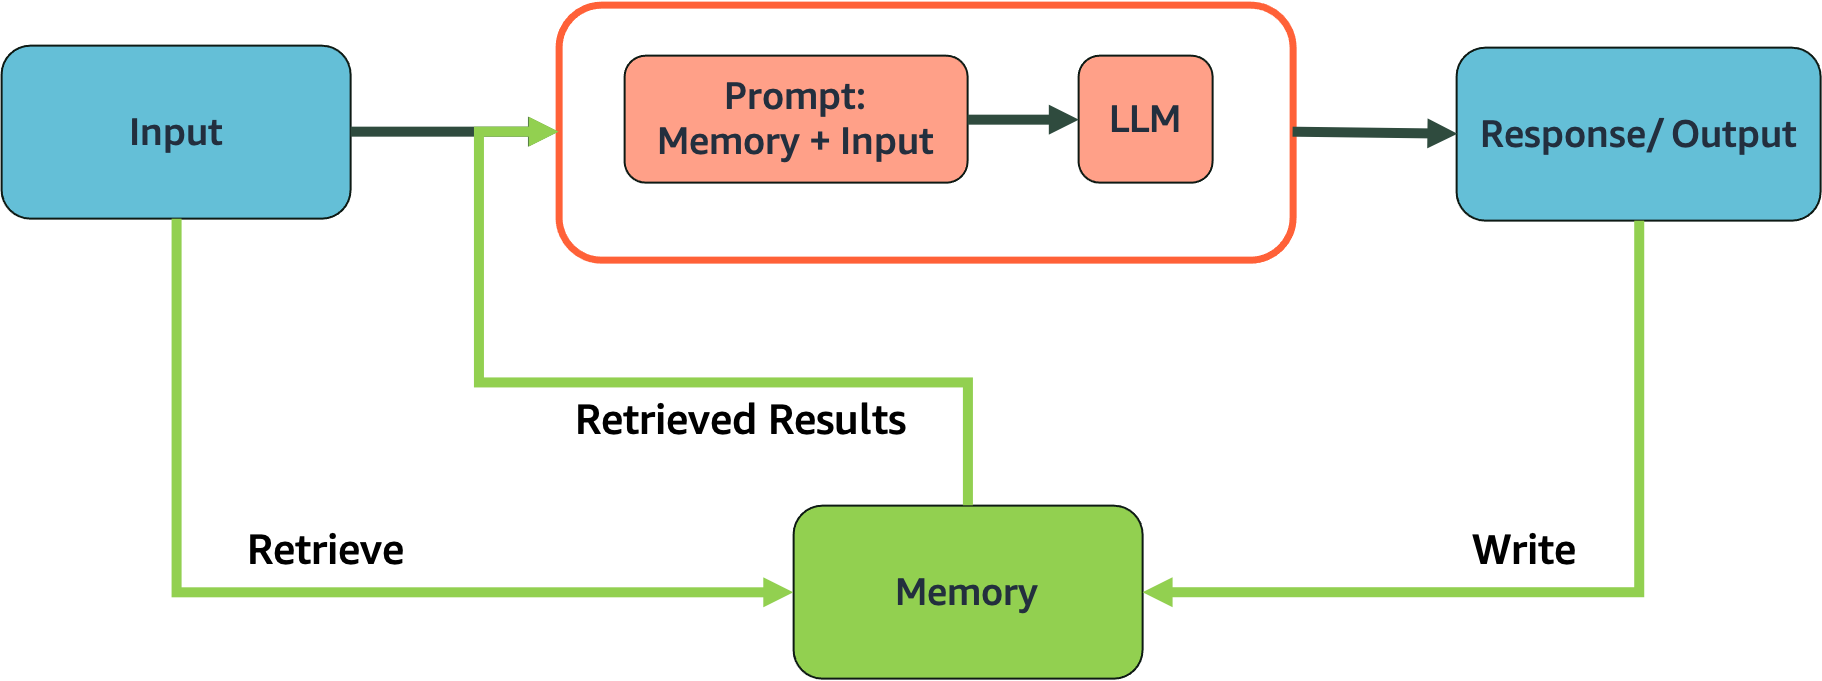
</div>

<!-- Important Note -->
<div style="background-color: #FDEDEC; border-left: 5px solid #E74C3C; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <p style="color: #C0392B; margin: 0;"><strong>Important:</strong> LangChain is deprecating the memory modules and asking users to use LangGraph instead. To keep the demos simple, we have implemented some of the memory modules we will be using in this course.</p>
</div>

Let's start with defining a helper function that will prompt the LLM multiple times and record the responses and how the memory component gets updated.

In [ ]:
def prompt_and_print_memory(prompts, chain_with_memory):
    # Store the responses
    responses = {"input": [], "history": [], "response": []}

    # Repeatedly prompting the chain and observing the memory
    for prompt in prompts:
        response = chain_with_memory(prompt)
        for key in response:
            responses[key].append(response[key])

    # Store and print the responses in a dataframe
    df = pd.DataFrame.from_dict(responses)
    with pd.option_context("display.max_colwidth", None):
        display(df)

In [ ]:
import pandas as pd
from IPython.display import display
from langchain.prompts import PromptTemplate


def create_memory_chain(llm):
    # Simple list-based memory
    memory_list = []
    
    # Create prompt template with system message
    prompt = PromptTemplate(
        input_variables=["chat_history", "input"],
        template="""You are a helpful, friendly AI assistant. Be concise and clear in your responses.

Previous conversation:
{chat_history}

Input: {input}""")
    
    # Define the chain using LCEL
    chain = prompt | llm | StrOutputParser()
    
    # Function to process messages with memory
    def process_message(user_input):
        # Format chat history from memory_list
        chat_history = ""
        for entry in memory_list:
            chat_history += f"Human: {entry['input']}\nAI: {entry['output']}\n\n"
        
        # Generate response using the chain
        response = chain.invoke({
            "chat_history": chat_history,
            "input": user_input
        })
        
        # Save to memory
        memory_list.append({"input": user_input, "output": response})
        
        return {"input": user_input, "history": chat_history, "response": response}
    
    return process_message

In [ ]:
# Create the memory-based chain
memory_chain = create_memory_chain(bedrock_llm)

# Sequence of prompts
prompts = [
    "What is Amazon Sagemaker?",
    "Can it help with deploying ML models?",
    "Do you need an AWS account to access it?",
]

# Use the helper function to sequentially prompt the chain and observe the memory
prompt_and_print_memory(prompts, memory_chain)

<!-- Activity Box -->
<div style="background-color: #EBF5FB; border-left: 5px solid #3498DB; padding: 15px; border-radius: 5px; margin: 20px 0; display: flex; align-items: flex-start;">
    <div style="flex: 0 0 60px; margin-right: 15px;">
        <img src="../mlu_utils/images/activity.png" alt="Activity" width="200" style="max-width: 100%; height: auto;">
    </div>
    <div style="flex: 1;">
        <h4 style="color: #2874A6; margin-top: 0;">Activity: Exploring memory in LLM conversations</h4>
        <p>Use this interactive widget to understand how memory modules enable LLMs to maintain context throughout a conversation.</p>
        <ul>
            <li>Start a conversation by asking a question or making a statement</li>
            <li>Follow up with questions that reference previous parts of the conversation (e.g., "Can you elaborate on that?" or "What did you mean by X?")</li>
            <li>Observe how the memory buffer on the right keeps track of the entire conversation history</li>
            <li>Notice how the LLM uses this memory to maintain context and provide coherent responses</li>
            <li>Try asking the model to recall specific information you mentioned earlier to test its memory capabilities</li>
        </ul>
    </div>
</div>

In [ ]:
from mlu_utils.widgets.memory_widget import create_memory_demo_ui
# Create and display the UI
memory_demo_ui = create_memory_demo_ui(bedrock_llm)
display(memory_demo_ui)

<!-- Section Header -->
<div id="section3" style="border-left: 5px solid #3498DB; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2874A6;">3. Simple chatbot</h2>
</div>

In this section, we explore how to build a basic yet functional chatbot using LangChain. The implementation demonstrates that a working chatbot requires just three essential components:

1. **The LLM (Large Language Model)**:  The model that powers the chatbot's responses
2. **A memory module**: To maintain conversation history, allowing the chatbot to remember previous interactions
3. **A prompt template**: To define the chatbot's personality and behavior

The code demonstrates a complete chatbot implementation that can maintain context across multiple conversation turns. The example conversation shows the chatbot answering questions about machine learning, remembering previous questions, and building upon earlier responses when asked follow-up questions.

This simple architecture provides a foundation that can be easily extended with additional capabilities as needed. The conversation flow demonstrates how the chatbot maintains context, making it feel more like a natural conversation rather than isolated question-answer pairs.

<!-- Important Note -->
<div style="background-color: #FDEDEC; border-left: 5px solid #E74C3C; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <p style="color: #C0392B; margin: 0;"><strong>Important:</strong> LangChain is deprecating the memory modules and asking users to use LangGraph instead. To keep the demos simple, we have implemented some of the memory modules we will be using in this course.</p>
</div>

In [ ]:
from mlu_utils.langchain_modules.memory_modules import ConversationBufferMemory

# Initialize memory
memory = ConversationBufferMemory(return_messages=True, memory_key="chat_history")

# Create prompt template with system message
prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful, friendly AI assistant. Be concise and clear in your responses."),
    ("placeholder", "{chat_history}"),
    ("human", "{input}")
])

# Define the chain
chain = prompt | bedrock_llm | StrOutputParser()

# Function to process messages
def chat(user_input):
    # Get chat history from memory
    chat_history = memory.load_memory_variables({}).get("chat_history", "")
    
    # Generate response using the prompt template
    # formatted_prompt = prompt.format(chat_history=chat_history, input=user_input)
    response = chain.invoke(
        {
            "chat_history" : chat_history,
            "input" : user_input
        }
    )
    
    # Save to memory
    memory.save_context({"input": user_input}, {"output": response})
    
    return response

Let's try chatting with our simple application. Note how the chatbot is able to continue a conversation with each follow-up question.

In [ ]:
# Print header
print("\n===== Simple Chatbot Demo =====\n")

# First user message
user_message = "What is machine learning?"
print(f"👤 User: {user_message}")
response = chat(user_message)
print(f"🤖 Bot:  {response}\n")

# Second user message (with memory of previous exchange)
user_message = "Can you give me a simple example?"
print(f"👤 User: {user_message}")
response = chat(user_message)
print(f"🤖 Bot:  {response}\n")

# Third user message to demonstrate continued context
user_message = "How is that different from traditional programming?"
print(f"👤 User: {user_message}")
response = chat(user_message)
print(f"🤖 Bot:  {response}\n")

print("===== End =====\n")

---
When building a chatbot, maintaining conversation history is crucial for context-aware responses. The `ConversationBufferMemory` provides an elegant solution for this requirement. `ConversationBufferMemory` stores the entire conversation history as a sequence of message objects. Each interaction between the user and the chatbot is preserved as a pair of messages:

- `HumanMessage`: Contains the user's input text
- `AIMessage`: Contains the chatbot's response text

These messages are stored in chronological order, creating a complete record of the conversation flow.

This structured approach to memory offers several advantages:
- Preserves the natural turn-taking of conversation
- Maintains the chronological order of interactions
- Distinguishes between user inputs and AI responses
- Allows the LLM to reference previous questions and its own answers

In our example chatbot, this memory system enables the assistant to understand follow-up questions and build upon its previous explanations about machine learning.

In [ ]:
from langchain.schema import HumanMessage, AIMessage

messages = memory.chat_memory.messages
# We can examine the structure of these messages
for i, message in enumerate(messages):
    message_type = "Human" if isinstance(message, HumanMessage) else "AI"
    print(f"Message {i+1} - Type: {message_type}")
    print(f"Content: {message.content[:50]}...")  # Print first 50 chars
    print()


<!-- Subsection Header -->
<div id="section3-1" style="border-left: 3px solid #85C1E9; padding-left: 12px; margin: 25px 0 15px 15px;">
    <h3 style="color: #2E86C1;">3.1 Simple chatbot application</h3>
</div>

Now that we understand the core components of a chatbot (LLM, memory, and prompt template), it's important to recognize how these fundamental building blocks can be extended into a complete, user-friendly application.

The full chatbot application we've built behind the scenes takes the same core logic we just explored and wraps it in a polished user interface. While the implementation details are abstracted away, the application follows the same principles:

**Core components remain the same:**
   - It still uses an LLM to generate responses
   - It maintains conversation history using `ConversationBufferMemory`
   - It structures interactions with a prompt template

The same `ConversationBufferMemory` we just examined is working behind the scenes, storing each exchange between the user and the AI as alternating `HumanMessage` and `AIMessage` objects. This memory system is what enables the chatbot to maintain context throughout the conversation, regardless of how sophisticated the user interface becomes.

<!-- Activity Box -->
<div style="background-color: #EBF5FB; border-left: 5px solid #3498DB; padding: 15px; border-radius: 5px; margin: 20px 0; display: flex; align-items: flex-start;">
    <div style="flex: 0 0 60px; margin-right: 15px;">
        <img src="../mlu_utils/images/activity.png" alt="Activity" width="200" style="max-width: 100%; height: auto;">
    </div>
    <div style="flex: 1;">
        <h4 style="color: #2874A6; margin-top: 0;">Activity: Test the chatbot</h4>
        <p>Run the cell below to test our simple chatbot with memory. Notice how it maintains context across multiple messages.</p>
        <ol>
            <li><strong>Customize the chatbot:</strong>
                <ul>
                    <li>Click on the "Settings" accordion to expand options</li>
                    <li>Modify the system message to change the chatbot's personality or role</li>
                    <li>Adjust the temperature slider (higher values = more creative responses)</li>
                    <li>Set max tokens to control response length (0 = no limit)</li>
                    <li>Click "Update Parameters" to apply your changes</li>
                </ul>
            </li>
            <li><strong>Chat with the bot:</strong>
                <ul>
                    <li>Type your message in the input box and press Enter or click Send</li>
                    <li>Ask follow-up questions to see how the bot maintains context</li>
                    <li>Try complex multi-turn conversations to test memory capabilities</li>
                </ul>
            </li>
            <li><strong>Experiment:</strong>
                <ul>
                    <li>Try different system prompts to see how they affect responses</li>
                    <li>Compare responses with different temperature settings</li>
                    <li>Use the "Clear Chat" button to start a fresh conversation</li>
                </ul>
            </li>
        </ol>
    </div>
</div>


<!-- Important Note -->
<div style="background-color: #FDEDEC; border-left: 5px solid #E74C3C; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <p style="color: #C0392B; margin: 0;"><strong>Important:</strong> This widget is for demo purposes only.</p>
</div>

In [ ]:
from mlu_utils.widgets.simple_chatbot import SimpleChatbot

chatbot = SimpleChatbot()
chatbot.display()

<!-- Section Header -->
<div id="section4" style="border-left: 5px solid #3498DB; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2874A6;">4. Conversational memory modules</h2>
</div>

When building conversational AI applications, the way your chatbot remembers and processes conversation history can significantly impact its performance. There are several specialized memory modules, each designed for different use cases and conversation patterns.

**Types of memory modules:**

- **`ConversationBufferMemory`**
  
This is the simplest form of memory that stores the entire conversation history. It's like having a perfect recall of everything that was said. While effective for short conversations, it can become inefficient with very long dialogues as the entire history is included in each prompt.

- **`ConversationBufferWindowMemory`**

This memory type maintains a sliding window of the most recent conversation exchanges. It helps manage token usage by only remembering the last `K` interactions, making it ideal for longer conversations where distant history is less relevant.

- **`ConversationSummaryMemory`**

Instead of storing the complete conversation verbatim, this memory type periodically summarizes older parts of the conversation. This approach helps maintain context while significantly reducing token usage for lengthy conversations.

**Choosing the right memory type:**

The best memory type depends on your specific use case:
- For simple, short conversations: `ConversationBufferMemory`
- For longer conversations with recent context: `ConversationBufferWindowMemory`
- For extended conversations where token efficiency matters: `ConversationSummaryMemory`

Each memory type offers a different balance between context preservation, token efficiency, and specialized functionality.

<!-- Activity Box -->
<div style="background-color: #EBF5FB; border-left: 5px solid #3498DB; padding: 15px; border-radius: 5px; margin: 20px 0; display: flex; align-items: flex-start;">
    <div style="flex: 0 0 60px; margin-right: 15px;">
        <img src="../mlu_utils/images/activity.png" alt="Activity" width="200" style="max-width: 100%; height: auto;">
    </div>
    <div style="flex: 1;">
        <h4 style="color: #2874A6; margin-top: 0;">Activity: Explore Different Memory Types</h4>
        <p>Run the cell below to launch the Memory Explorer widget. This tool allows you to compare how different memory types handle the same conversation.</p>
        <ol>
            <li><strong>Using the Memory Explorer:</strong>
                <ul>
                    <li>Select a memory type from the dropdown menu</li>
                    <li>Type messages in the input box to simulate a conversation</li>
                    <li>Observe how the selected memory type processes and stores the conversation</li>
                </ul>
            </li>
            <li><strong>Compare Memory Types:</strong>
                <ul>
                    <li>Switch between different memory types to see how they handle the same conversation</li>
                    <li>Pay attention to the "Memory Content" section that shows what's actually stored</li>
                    <li>For window memory, try adjusting the window size parameter</li>
                    <li>For summary memory, notice how it condenses previous exchanges</li>
                </ul>
            </li>
            <li><strong>Experiment with Scenarios:</strong>
                <ul>
                    <li>Try a long conversation to see how each memory type handles increasing context</li>
                    <li>Introduce specific entities (people, places) to see how entity memory tracks them</li>
                    <li>Circle back to previously discussed topics to test how well each memory type maintains context</li>
                </ul>
            </li>
        </ol>
        <p><strong>Reflection Question:</strong> Which memory type would be most appropriate for a customer service chatbot that needs to handle potentially long conversations while remembering key customer details?</p>
    </div>
</div>

In [ ]:
from mlu_utils.widgets.memory_widget import create_configurable_memory_demo_ui

memory_demo_ui = create_configurable_memory_demo_ui(bedrock_llm)
display(memory_demo_ui)

<!-- Section Header -->
<div id="section5" style="border-left: 5px solid #3498DB; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2874A6;">5. Caching responses</h2>
</div>

Working with LLMs can be both computationally intensive and costly, especially when making repeated API calls. Caching provides a solution by storing responses to previous queries, allowing your application to retrieve them instantly rather than generating them again.

**Benefits of caching:**

- **Cost reduction**: Fewer API calls means lower costs, especially important when using commercial LLM services.
- **Improved response time**: Cached responses are returned almost instantly, significantly improving user experience.
- **Reduced computational load**: Less processing power is required when responses are retrieved from cache.
- **Consistency**: The same query will always return the same response if cached, ensuring consistent behavior.

**Types of caching in LangChain:**

**In-memory caching**

This approach stores responses in the application's memory during runtime. It's simple to implement and provides the fastest response times. However, the cache is lost when the application restarts, making it suitable for short-lived sessions or development environments.

**Persistent caching with SQLite**

This method stores cached responses in a SQLite database, allowing them to persist between application restarts. It's ideal for production environments where maintaining cache across sessions is valuable.

**Caching considerations:**

- Caching works best for deterministic queries (`temperature=0`) where the same input should produce the same output
- For creative or randomized responses (higher temperature), caching might limit the diversity of responses
- Consider implementing cache expiration for use cases where information might become outdated
- Be mindful of storage requirements for persistent caches with large numbers of queries

Implementing caching is a simple yet effective optimization that can dramatically improve both the performance and cost-efficiency of your LLM applications.

<!-- Subsection Header -->
<div id="section5-1" style="border-left: 3px solid #85C1E9; padding-left: 12px; margin: 25px 0 15px 15px;">
    <h3 style="color: #2E86C1;">5.1 In-memory cache</h3>
    <p>The simplest form of caching that stores responses in memory during the session.</p>
</div>

In [ ]:
# In Memory 
from langchain_core.globals import set_llm_cache

from langchain_core.caches import InMemoryCache

set_llm_cache(InMemoryCache())

chain = bedrock_llm | StrOutputParser()

<!-- Activity Box -->
<div style="background-color: #EBF5FB; border-left: 5px solid #3498DB; padding: 15px; border-radius: 5px; margin: 20px 0; display: flex; align-items: flex-start;">
    <div style="flex: 0 0 60px; margin-right: 15px;">
        <img src="../mlu_utils/images/activity.png" alt="Activity" width="200" style="max-width: 100%; height: auto;">
    </div>
    <div style="flex: 1;">
        <h4 style="color: #2874A6; margin-top: 0;">Activity: Test in-memory caching</h4>
        <p>Run the cells below to see how in-memory caching affects response time. The first call will be slow, but the second call should be much faster.</p>
    </div>
</div>

In [ ]:
%%time
# The first time, it is not yet in cache, so it should take longer
Markdown(chain.invoke("Tell me a joke"))

In [ ]:
%%time
# The second time, it should be retrieved from cache and be much faster
Markdown(chain.invoke("Tell me a joke"))

<!-- Subsection Header -->
<div id="section5-2" style="border-left: 3px solid #85C1E9; padding-left: 12px; margin: 25px 0 15px 15px;">
    <h3 style="color: #2E86C1;">5.2 SQLite cache</h3>
    <p>A persistent cache that stores responses in a SQLite database.</p>
</div>

In [ ]:
!rm -f .langchain.db

In [ ]:
from langchain_community.cache import SQLiteCache

set_llm_cache(SQLiteCache(database_path=".langchain.db"))

<!-- Activity Box -->
<div style="background-color: #EBF5FB; border-left: 5px solid #3498DB; padding: 15px; border-radius: 5px; margin: 20px 0; display: flex; align-items: flex-start;">
    <div style="flex: 0 0 60px; margin-right: 15px;">
        <img src="../mlu_utils/images/activity.png" alt="Activity" width="200" style="max-width: 100%; height: auto;">
    </div>
    <div style="flex: 1;">
        <h4 style="color: #2874A6; margin-top: 0;">Activity: Test SQLite caching</h4>
        <p>Run the cells below to see how SQLite caching works. The advantage of SQLite caching is that it persists between sessions.</p>
    </div>
</div>

In [ ]:
%%time
# The first time, it is not yet in cache, so it should take longer
Markdown(chain.invoke("Tell me a joke"))

In [ ]:
%%time
# The second time, it should be retrieved from cache and be much faster
Markdown(chain.invoke("Tell me a joke"))

<!-- Section Header -->
<div id="section6" style="border-left: 5px solid #3498DB; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2874A6;">6. Chatting with documents</h2>
</div>

LLMs can become even more powerful when they can access and analyze external data sources like documents. This capability allows users to have interactive conversations about specific content without having to manually search through documents themselves.

**The simple approach: document injection**

The simplest way to enable document-based conversations is through direct injection of document content into the prompt. This approach works as follows:

- The document text is extracted (e.g., from a PDF file)
- The content is inserted directly into the system prompt
- The LLM can then reference this information when answering questions

This method is straightforward and works well for smaller documents, as we're demonstrating in our example. The document content becomes part of the context that the model uses to generate responses.

**Advantages of document injection:**

- **Simple implementation**: No complex architecture required
- **Immediate context**: The model has direct access to the document content
- **No additional training**: Uses the LLM's existing capabilities to understand and analyze text

**Limitations to consider:**

- **Context window constraints**: Most LLMs have a maximum input size (context window), limiting the document length that can be processed
- **Lack of document structure awareness**: The model receives plain text without understanding the original formatting or structure
- **No search optimization**: The entire document is processed for every query, which can be inefficient

**When to use this approach:**

This simple document injection approach is ideal for:
- Short to medium-length documents (a few pages)
- Quick prototyping and demonstrations
- Use cases where the entire document content is relevant to most queries

For more complex document processing needs involving longer documents or multiple files, more advanced techniques like retrieval-augmented generation (RAG) would be more appropriate, which we'll explore in later sections.

<!-- Activity Box -->
<div style="background-color: #EBF5FB; border-left: 5px solid #3498DB; padding: 15px; border-radius: 5px; margin: 20px 0; display: flex; align-items: flex-start;">
    <div style="flex: 0 0 60px; margin-right: 15px;">
        <img src="../mlu_utils/images/activity.png" alt="Activity" width="200" style="max-width: 100%; height: auto;">
    </div>
    <div style="flex: 1;">
        <p style="color: #2874A6; font-weight: bold; margin-top: 0;">Activity: Chat with a document</p>
        <p>Run the cell below to launch the Document Chatbot. This tool allows you to upload a PDF and ask questions about its content.</p>
        <p><strong>Using the Document Chatbot:</strong></p>
        <ul>
            <li>Click on the "Settings" accordion to expand options</li>
            <li>Upload a PDF document using the file selector (note: only the first 3 pages will be processed)</li>
            <li>Ask questions about the document content in the chat interface</li>
            <li>Try asking for summaries, explanations, or specific information from the document</li>
        </ul>
        <p><strong>Experiment with different documents:</strong></p>
        <ul>
            <li>Try uploading different types of documents (articles, reports, etc.)</li>
            <li>Compare how well the chatbot handles structured vs. unstructured content</li>
            <li>Test the limits by asking about details from different sections of the document</li>
        </ul>
        <p><strong>Reflection questions:</strong></p>
        <ul>
            <li>How accurately does the chatbot answer questions about the document?</li>
            <li>What are the limitations you notice with this simple document injection approach?</li>
            <li>What types of documents or use cases would benefit most from this capability?</li>
        </ul>
    </div>
</div>

<!-- Important Note -->
<div style="background-color: #FDEDEC; border-left: 5px solid #E74C3C; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <p style="color: #C0392B; margin: 0;"><strong>Important:</strong> The application only ingests up to 3 pages from the PDF. Longer PDFs may cause expected issues due to this limitation. Additionally, be mindful of the size of the PDF. The uploader may not accept very large PDF files.</p>
</div>

In [ ]:
from mlu_utils.widgets.simple_chatbot import ChatbotwithPdfSupport

chatbot = ChatbotwithPdfSupport()
chatbot.display()

<!-- Section Header -->
<div id="section1" style="border-left: 5px solid #3498DB; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2874A6;">6. Quizzes</h2>
</div>

<!-- Challenge Box -->
<div style="background-color: #FEF9E7; border-left: 5px solid #F1C40F; padding: 15px; border-radius: 5px; margin: 20px 0; display: flex; align-items: flex-start;">
    <div style="flex: 0 0 60px; margin-right: 15px;">
        <img src="../mlu_utils/images/challenge.png" alt="Challenge" width="200" style="max-width: 100%; height: auto;">
    </div>
    <div style="flex: 1;">
        <h4 style="color: #B7950B; margin-top: 0;">Challenge: Quizzes</h4>
        <p>Answer the following questions to test your understanding of conversational applications.</p>
    </div>
</div>

In [ ]:
from mlu_utils.quiz_questions import lab2_question1, lab2_question2

lab2_question1.display()
lab2_question2.display()

<div style="background-color: #EBF5FB; padding: 15px; border-radius: 5px; margin: 30px 0;">
    <h3 style="color: #2874A6; border-bottom: 1px solid #85C1E9; padding-bottom: 5px;">Conclusion</h3>
    <p>In this lab, you have:</p>
    <ul>
        <li>Set up a chat model using Amazon Bedrock and Claude 3</li>
        <li>Created chat prompt templates for structured conversations</li>
        <li>Analyzed the effectiveness of the memory module in recalling past interactions</li>
        <li>Built a simple chatbot with memory capabilities</li>
        <li>Explored different memory modules for conversation management</li>
        <li>Implemented caching to improve performance</li>
        <li>Created a document-based Q&A system</li>
    </ul>
    <h4 style="color: #2874A6; margin-top: 15px;">Additional resources</h4>
    <ul>
        <li><a href="https://python.langchain.com/docs/modules/memory/">LangChain Memory Documentation</a></li>
        <li><a href="https://python.langchain.com/docs/modules/model_io/prompts/prompt_templates/">LangChain Prompt Templates</a></li>
        <li><a href="https://python.langchain.com/docs/integrations/chat/bedrock">Amazon Bedrock Integration</a></li>
    </ul>
</div>

<p style="padding: 10px; border: 1px solid black;">
<img src="../mlu_utils/images/MLU-NEW-logo.png" alt="drawing" width="400"/> <br/>

# Thank you!